# Training UDEs: another idea

**Idea.** Instead of training the UDE models on a single time series simulation, try with more.

The model is still the generalised logistic model, with the same parameters as the previous notebooks.

In [1]:
# modules
from torch import nn
import torch 
import pysindy as ps
from sr3_modified import my_SR3 as SR3
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
from torchdiffeq import odeint
from scipy.integrate import quad

In [2]:
# define the model same as before
k = 6
rho0 = 1
rho = np.array(
    [0, 0.25, 0.1, 0.001, 1]
)

def generalised_growth(t, data, k, rho):
    x = data[0]
    powers = np.arange(1, k)
    x_pow = np.power(x, powers)

    return np.array(
        [rho0 * x * (1 - np.dot(x_pow, rho)) ]
    )


In [3]:
# helper function for polynomial definition

def poly_sindy(x, deg: int, model: ps.SINDy):
    # evaluates a polynomial of degree deg with trained SINDy model's coefficient
    p = np.zeros(deg)
    p[1:] = model.coefficients()

    p = p[::-1]

    return np.polyval(p, x)

def poly_real(x, deg):
    p = np.zeros(deg)

    p[1] = 1

    p[2:] = -rho0 * rho.reshape(deg-2)

    p = p[::-1]

    return np.polyval(p, x)


In [4]:
# We will consider two extremal cases: small initial condition and big initial condition

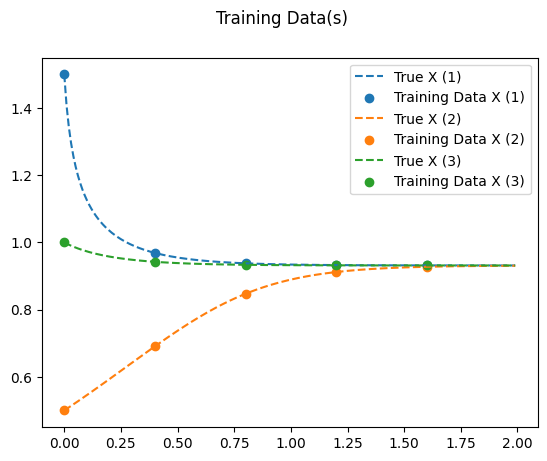

In [61]:
T_MAX = 2.

x01 = 1.5

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x01], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X (1)")


T_train1 = T[::40]
X_train1 = X[::40]

plt.scatter(T_train1, X_train1, label="Training Data X (1)")

# 2

T_MAX = 2

x02 = 0.5

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x02], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X (2)")


T_train2 = T[::40]
X_train2 = X[::40]

plt.scatter(T_train2, X_train2, label="Training Data X (2)")

# 3

T_MAX = 2

x03 = 1.0

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x03], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X (3)")


T_train3 = T[::40]
X_train3 = X[::40]

plt.scatter(T_train3, X_train3, label="Training Data X (3)")


plt.legend()

plt.suptitle("Training Data(s)")
plt.show()

In [59]:
# train the baseline model on the first dataset
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=5000, verbose=True)
)
model_old.fit(X_train1.reshape(-1, 1), T_train1, feature_names=['x'])

model_old.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.4059e-01 ... 1.2924e-03 ... 3.0000e-02 ... 3.7188e-01
         1 ... 2.9636e-01 ... 1.2209e-02 ... 3.0000e-02 ... 3.3857e-01
         2 ... 2.9649e-01 ... 3.9040e-04 ... 3.0000e-02 ... 3.2688e-01
         3 ... 2.9600e-01 ... 4.4975e-04 ... 3.0000e-02 ... 3.2644e-01
         4 ... 2.9559e-01 ... 5.6197e-04 ... 3.0000e-02 ... 3.2615e-01
         5 ... 2.9521e-01 ... 6.8192e-04 ... 3.0000e-02 ... 3.2589e-01
         6 ... 2.9485e-01 ... 8.0449e-04 ... 3.0000e-02 ... 3.2565e-01
         7 ... 2.9451e-01 ... 9.2752e-04 ... 3.0000e-02 ... 3.2544e-01
         8 ... 2.9419e-01 ... 1.0494e-03 ... 3.0000e-02 ... 3.2524e-01
         9 ... 2.9389e-01 ... 1.1691e-03 ... 3.0000e-02 ... 3.2506e-01
        10 ... 2.9361e-01 ... 1.2855e-03 ... 3.0000e-02 ... 3.2489e-01
        11 ... 2.9334e-01 ... 1.3980e-03 ... 3.0000e-02 ... 3.2474e-01
        12 ... 2.9309e-01 ... 1.5062e-03 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 5000 iterations.
  warnings.warn(


In [60]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

train two models: one with the 2nd dataset, another one without

In [69]:
my_growth = ude_generalised_growth(rho0)

lr = 0.001
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)
rtol = 1e-7

n_epochs = 5000

t_train_torch1 = torch.tensor(T_train1, dtype=torch.float32)
t_train_torch2 = torch.tensor(T_train2, dtype=torch.float32)
t_train_torch3 = torch.tensor(T_train3, dtype=torch.float32)
x0_torch1 = torch.tensor([x01], dtype=torch.float32, requires_grad=True)
x0_torch2 = torch.tensor([x02], dtype=torch.float32, requires_grad=True)
x0_torch3 = torch.tensor([x03], dtype=torch.float32, requires_grad=True)
x_train_torch1 = torch.tensor(X_train1, dtype=torch.float32).view(-1, 1)
x_train_torch2 = torch.tensor(X_train2, dtype=torch.float32).view(-1, 1)
x_train_torch3 = torch.tensor(X_train3, dtype=torch.float32).view(-1, 1)

losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    x0_torch1,
                    t_train_torch1,
                    rtol=1e-9, atol=1e-9,
                    method='rk4'
                    )
    
    # Compute loss at training points
    loss = torch.sum(torch.pow(x_pred-x_train_torch1, 2))

    x_pred = odeint(my_growth, 
                    x0_torch2,
                    t_train_torch2,
                    rtol=1e-9, atol=1e-9,
                    method='rk4'
                    )

    loss += torch.sum(torch.pow(x_pred-x_train_torch2, 2))

    x_pred = odeint(my_growth, 
                    x0_torch3,
                    t_train_torch3,
                    rtol=1e-9, atol=1e-9,
                    method='rk4'
                    )

    loss += torch.sum(torch.pow(x_pred-x_train_torch3, 2))


    loss /= (X_train1.shape[0] + X_train2.shape[0] + X_train3.shape[0])

    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses.append(loss.detach())
        print(f"{EPOCH}\t{loss.item()}")




0	0.09009811282157898
1	0.08528339862823486
2	0.08254458010196686
3	0.08123406767845154
4	0.08066581189632416
5	0.08026942610740662
6	0.07971629500389099
7	0.07889848202466965
8	0.07783631235361099
9	0.07660498470067978
10	0.07529304176568985
11	0.07398004084825516
12	0.07272401452064514
13	0.0715535506606102
14	0.07046429067850113
15	0.06942236423492432
16	0.06837626546621323
17	0.06727461516857147
18	0.06608216464519501
19	0.06478781253099442
20	0.06340339034795761
21	0.06195488199591637
22	0.0604710578918457
23	0.05897277593612671
24	0.05746662616729736
25	0.055943895131349564
26	0.05438550189137459
27	0.052770502865314484
28	0.05108451470732689
29	0.04932485148310661
30	0.04750122129917145
31	0.045632388442754745
32	0.04373998939990997
33	0.04184144362807274
34	0.039944492280483246
35	0.03804624453186989
36	0.03613821417093277
37	0.034215155988931656
38	0.03228246420621872
39	0.030357060953974724
40	0.02846159227192402
41	0.026615720242261887
42	0.024829916656017303
43	0.0231054015

In [80]:
torch.save(my_growth.state_dict(), "./models_weights/logistic_mixed.dinomeng")

In [64]:
my_growth_base = ude_generalised_growth(rho0)

lr = 0.001
optimizer = torch.optim.Adam(my_growth_base.parameters(), lr=lr)
rtol = 1e-7

n_epochs = 1000

t_train_torch1 = torch.tensor(T_train1, dtype=torch.float32)
t_train_torch2 = torch.tensor(T_train2, dtype=torch.float32)
x0_torch1 = torch.tensor([x01], dtype=torch.float32, requires_grad=True)
x0_torch2 = torch.tensor([x02], dtype=torch.float32, requires_grad=True)
x_train_torch1 = torch.tensor(X_train1, dtype=torch.float32).view(-1, 1)
x_train_torch2 = torch.tensor(X_train2, dtype=torch.float32).view(-1, 1)

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth_base, 
                    x0_torch1,
                    t_train_torch1,
                    rtol=1e-9, atol=1e-9,
                    method='rk4'
                    )
    
    # Compute loss at training points
    loss = torch.sum(torch.pow(x_pred-x_train_torch1, 2))

    loss /= (X_train1.shape[0])

    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        print(f"{EPOCH}\t{loss.item()}")




0	0.3214742839336395
1	0.27104857563972473
2	0.22704000771045685
3	0.18893571197986603
4	0.15623807907104492
5	0.1284622848033905
6	0.10512937605381012
7	0.08577355742454529
8	0.06994633376598358
9	0.05721842125058174
10	0.04718270152807236
11	0.03945688530802727
12	0.033686183393001556
13	0.029544970020651817
14	0.026737982407212257
15	0.025000769644975662
16	0.024099458009004593
17	0.023830030113458633
18	0.02401726134121418
19	0.02451322041451931
20	0.025195619091391563
21	0.025965789332985878
22	0.026746492832899094
23	0.027479585260152817
24	0.02812339924275875
25	0.028650369495153427
26	0.02904457412660122
27	0.029299601912498474
28	0.02941659651696682
29	0.02940254472196102
30	0.029268821701407433
31	0.02902989089488983
32	0.028702232986688614
33	0.028303449973464012
34	0.027851516380906105
35	0.027364034205675125
36	0.026857798919081688
37	0.02634824439883232
38	0.025849204510450363
39	0.025372538715600967
40	0.024928009137511253
41	0.02452317252755165
42	0.024163343012332916
4

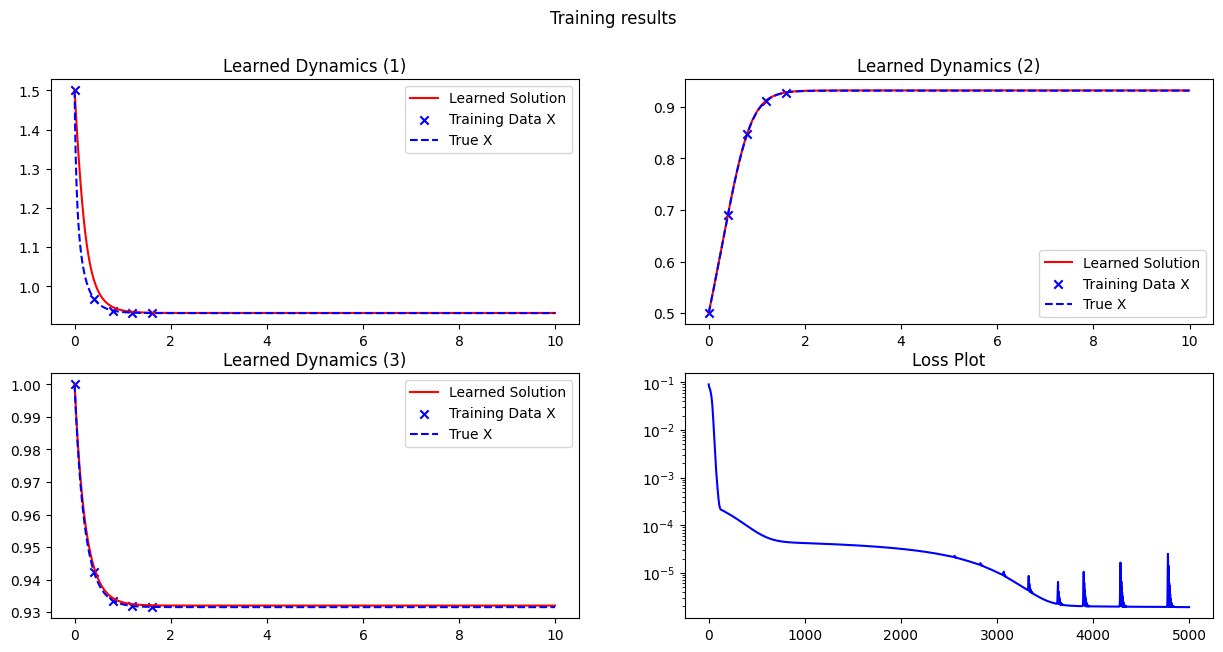

In [78]:
T_MAX = 10
fig, axes = plt.subplots(2,2, figsize=(15,7))

x_pred = odeint(my_growth, 
                x0_torch1,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x01], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func = axes[0,0]
func2 = axes[0,1]
func3 = axes[1,0]
loss = axes[1,1]

func.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func.scatter(T_train1, X_train1, label="Training Data X", color='blue', marker='x')
func.plot(T, X, "--", label="True X", color='blue')
func.legend()
func.set_title("Learned Dynamics (1)")


T_MAX = 10

x_pred = odeint(my_growth, 
                x0_torch2,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x02], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func2.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func2.scatter(T_train2, X_train2, label="Training Data X", color='blue', marker='x')
func2.plot(T, X, "--", label="True X", color='blue')
func2.legend()
func2.set_title("Learned Dynamics (2)")

T_MAX = 10

x_pred = odeint(my_growth, 
                x0_torch3,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x03], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func3.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func3.scatter(T_train3, X_train3, label="Training Data X", color='blue', marker='x')
func3.plot(T, X, "--", label="True X", color='blue')
func3.legend()
func3.set_title("Learned Dynamics (3)")


loss.semilogy(losses, color="blue")
loss.set_title("Loss Plot")

plt.suptitle("Training results")

plt.show()

In [73]:
X_dot = torch.zeros(T_train1.shape[0])

for i, (t, x) in enumerate(zip(T_train1, X_train1)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True)
)

model.fit(X_train1.reshape(-1, 1), T_train1, feature_names=['x'], x_dot=X_dot.detach().numpy().reshape(-1, 1))


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.4127e-02 ... 9.3492e-04 ... 3.0000e-02 ... 6.5062e-02
         1 ... 7.4795e-03 ... 6.3614e-06 ... 3.0000e-02 ... 3.7486e-02
         2 ... 7.1226e-03 ... 3.0270e-05 ... 3.0000e-02 ... 3.7153e-02
         3 ... 7.1112e-03 ... 2.9110e-05 ... 3.0000e-02 ... 3.7140e-02
         4 ... 7.1064e-03 ... 2.5786e-05 ... 3.0000e-02 ... 3.7132e-02
         5 ... 7.1013e-03 ... 2.3284e-05 ... 3.0000e-02 ... 3.7125e-02
         6 ... 7.0956e-03 ... 2.1547e-05 ... 3.0000e-02 ... 3.7117e-02
         7 ... 7.0895e-03 ... 2.0344e-05 ... 3.0000e-02 ... 3.7110e-02
         8 ... 7.0832e-03 ... 1.9502e-05 ... 3.0000e-02 ... 3.7103e-02
         9 ... 7.0765e-03 ... 1.8908e-05 ... 3.0000e-02 ... 3.7095e-02
        10 ... 7.0698e-03 ... 1.8485e-05 ... 3.0000e-02 ... 3.7088e-02
        11 ... 7.0629e-03 ... 1.8182e-05 ... 3.0000e-02 ... 3.7081e-02
        12 ... 7.0560e-03 ... 1.7962e-05 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


In [74]:
X_dot = torch.zeros(T_train1.shape[0])

for i, (t, x) in enumerate(zip(T_train1, X_train1)):
    X_dot[i] = my_growth_base(t, torch.tensor([x], dtype=torch.float32))

model_base = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True)
)

model_base.fit(X_train1.reshape(-1, 1), T_train1, feature_names=['x'], x_dot=X_dot.detach().numpy().reshape(-1, 1))

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 4.2178e-02 ... 7.7955e-04 ... 3.0000e-02 ... 7.2958e-02
         1 ... 1.3643e-02 ... 3.0815e-05 ... 3.0000e-02 ... 4.3674e-02
         2 ... 1.3243e-02 ... 6.6814e-05 ... 3.0000e-02 ... 4.3310e-02
         3 ... 1.3228e-02 ... 6.0002e-05 ... 3.0000e-02 ... 4.3288e-02
         4 ... 1.3220e-02 ... 5.1728e-05 ... 3.0000e-02 ... 4.3272e-02
         5 ... 1.3212e-02 ... 4.5834e-05 ... 3.0000e-02 ... 4.3258e-02
         6 ... 1.3202e-02 ... 4.1805e-05 ... 3.0000e-02 ... 4.3244e-02
         7 ... 1.3191e-02 ... 3.9035e-05 ... 3.0000e-02 ... 4.3230e-02
         8 ... 1.3179e-02 ... 3.7110e-05 ... 3.0000e-02 ... 4.3216e-02
         9 ... 1.3167e-02 ... 3.5758e-05 ... 3.0000e-02 ... 4.3203e-02
        10 ... 1.3155e-02 ... 3.4801e-05 ... 3.0000e-02 ... 4.3190e-02
        11 ... 1.3142e-02 ... 3.4118e-05 ... 3.0000e-02 ... 4.3176e-02
        12 ... 1.3129e-02 ... 3.3626e-05 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


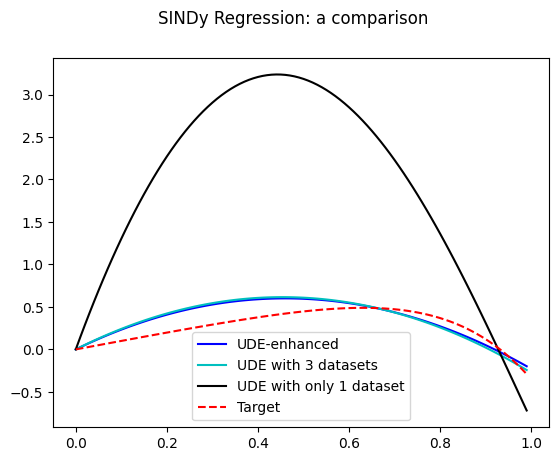

Baseline	3.783e+00
UDE	2.065e-02
UDE Base	2.408e-02


In [81]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="UDE-enhanced")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_base), "c", label="UDE with 3 datasets")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="UDE with only 1 dataset")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="Target")

plt.suptitle("SINDy Regression: a comparison")

plt.legend()

plt.show()

def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

def poly_diff3(x):
    return (poly_sindy(x, k+1, model_base)-poly_real(x, k+1))**2

print(f"Baseline\t{quad(poly_diff2, 0, 1)[0]:.3e}\nUDE\t{quad(poly_diff1, 0, 1)[0]:.3e}\nUDE Base\t{quad(poly_diff3, 0,1)[0]:.3e}")

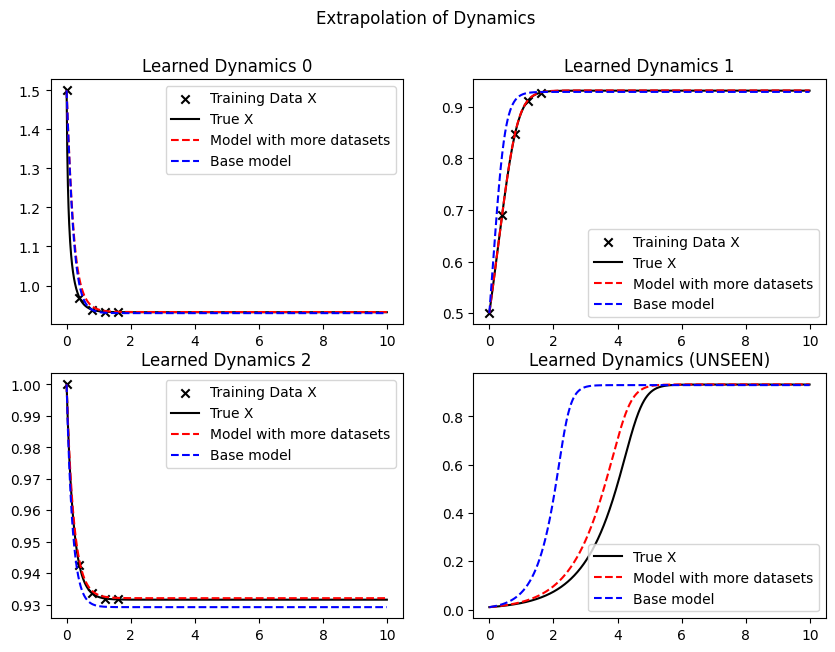

In [112]:
# Compare the extrapolations in terms of different initial states
fig, axes = plt.subplots(2,2, figsize=(10,7))



for i in range(4):
    if i == 0:
        x0_torch = x0_torch1
        x0 = x01
        T_train = T_train1 
        X_train = X_train1 
    elif i==1:
        x0_torch = x0_torch2
        x0 = x02
        T_train = T_train2
        X_train = X_train2 
    elif i==2:
        x0_torch = x0_torch3
        x0 = x03
        T_train = T_train3
        X_train = X_train3
    elif i == 3:
        x0 = 0.01
        x0_torch = torch.tensor([x0], dtype=torch.float32)

    pos_i, pos_j = divmod(i, 2)

    func = axes[pos_i, pos_j]
    T_MAX = 10
    x_pred = odeint(my_growth, 
                    x0_torch,
                    T_torch := torch.arange(0, T_MAX, 0.01)
                    )
    
    x_pred_base = odeint(my_growth_base, 
                    x0_torch,
                    T_torch := torch.arange(0, T_MAX, 0.01)
                    )

    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    T = sol.t
    X = sol.y[0]
    if i != 3:
        func.scatter(T_train, X_train, label="Training Data X", color='black', marker='x')
        
    func.plot(T, X, label="True X", color='black')

    func.plot(T_torch, x_pred.detach().numpy(), label="Model with more datasets", color='red', linestyle="--")
    func.plot(T_torch, x_pred_base.detach().numpy(), label="Base model", color='blue', linestyle="--")
    func.legend()
    func.set_title(f"Learned Dynamics {i}")

    if i == 3:
        func.set_title("Learned Dynamics (UNSEEN)")

plt.suptitle("Extrapolation of Dynamics")
plt.show()